# OANDA EURUSD Data Fetcher

Fetch EURUSD OHLCV data at 1-hour (H1) and 5-minute (M5) intervals for 2023

In [5]:
import v20
import pandas as pd
from datetime import datetime, timedelta
import time
import os
import json
import matplotlib.pyplot as plt
import pandas_ta as ta
import numpy as np


## OANDA Account Setup

1. Create a practice account at https://www.oanda.com/demo-account/
2. Get your API token from the 'Manage API Access' section
3. We'll fetch the account ID automatically below

In [3]:
# OANDA API Configuration
API_URL = 'api-fxpractice.oanda.com'
ACCESS_TOKEN = 'c3cb7c6a198247f404843c4878d4295b-ce3f4461613aab8832675ea50762c281'  # Replace with your token

# Initialize API connection
api = v20.Context(
    API_URL,
    443,
    token=ACCESS_TOKEN
)

# Get account ID automatically
try:
    response = api.account.list()
    if response.status != 200:
        raise Exception(f'Error getting account list: {response.status}')
        
    accounts = response.body['accounts']
    if not accounts:
        raise Exception('No accounts found')
        
    ACCOUNT_ID = accounts[0].id  # Use the first available account
    print(f'Successfully retrieved account ID: {ACCOUNT_ID}')
except Exception as e:
    print(f'Error: {e}')
    print('Please check your API token and connection')

Successfully retrieved account ID: 101-004-31500681-001


In [6]:
def fetch_candles(instrument, granularity, start_date, end_date):
    candles = []
    current_date = start_date
    
    while current_date < end_date:
        next_date = min(current_date + timedelta(days=5), end_date)
        
        params = {
            'from': current_date.isoformat('T') + 'Z',
            'to': next_date.isoformat('T') + 'Z',
            'granularity': granularity,
            'price': 'MBA'  # Bid/Mid/Ask
        }
        
        try:
            response = api.instrument.candles(instrument, **params)
            # Access the candles directly from response.body
            if hasattr(response, 'body') and 'candles' in response.body:
                candles.extend(response.body['candles'])
            else:
                print(f'No candles in response for {current_date}')
        except Exception as e:
            print(f'Error fetching data: {str(e)}')
            break
            
        current_date = next_date
        time.sleep(0.5)  # Rate limiting
    
    return candles

In [7]:
# Set date range
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

# Fetch H1 and M5 data
h1_candles = fetch_candles('EUR_USD', 'H1', start_date, end_date)
m5_candles = fetch_candles('EUR_USD', 'M5', start_date, end_date)

print(f'Fetched {len(h1_candles)} H1 candles')
print(f'Fetched {len(m5_candles)} M5 candles')

Fetched 36500 H1 candles
Fetched 36500 M5 candles


In [8]:
def process_candles(candles):
    data = []
    for candle in candles:
        if candle.complete:
            data.append({
                'datetime': candle.time,
                'open': float(candle.mid.o),
                'high': float(candle.mid.h),
                'low': float(candle.mid.l),
                'close': float(candle.mid.c),
                'volume': int(candle.volume)
            })
    return pd.DataFrame(data)

# Convert to DataFrames and save
h1_df = process_candles(h1_candles)
m5_df = process_candles(m5_candles)

h1_df.to_csv('H1.csv', index=False)
m5_df.to_csv('M5.csv', index=False)

In [9]:
# Display sample of H1 data
print("H1 Data Sample:")
display(h1_df.head())

print("\nM5 Data Sample:")
display(m5_df.head())

H1 Data Sample:


,datetime,open,high,low,close,volume
0,2025-03-24T21:00:00.000000000Z,1.08013,1.08019,1.07973,1.08006,739
1,2025-03-24T22:00:00.000000000Z,1.08006,1.08030,1.07952,1.08026,926
2,2025-03-24T23:00:00.000000000Z,1.08027,1.08038,1.08006,1.08026,1056
3,2025-03-25T00:00:00.000000000Z,1.08025,1.08030,1.07962,1.08002,2514
4,2025-03-25T01:00:00.000000000Z,1.08002,1.08087,1.08000,1.08022,3776



M5 Data Sample:


,datetime,open,high,low,close,volume
0,2025-04-20T22:35:00.000000000Z,1.14273,1.14274,1.14198,1.14250,533
1,2025-04-20T22:40:00.000000000Z,1.14248,1.14301,1.14182,1.14298,552
2,2025-04-20T22:45:00.000000000Z,1.14298,1.14324,1.14296,1.14313,411
3,2025-04-20T22:50:00.000000000Z,1.14312,1.14367,1.14308,1.14358,284
4,2025-04-20T22:55:00.000000000Z,1.14360,1.14372,1.14257,1.14332,548


In [6]:
# Load the data
h1_data = pd.read_csv('H1_cleaned.csv')
m5_data = pd.read_csv('M5_cleaned.csv')

# Convert datetime columns if needed
if 'datetime' in h1_data.columns or 'time' in h1_data.columns:
    datetime_col = 'datetime' if 'datetime' in h1_data.columns else 'time'
    h1_data[datetime_col] = pd.to_datetime(h1_data[datetime_col])
    h1_data.set_index(datetime_col, inplace=True)

if 'datetime' in m5_data.columns or 'time' in m5_data.columns:
    datetime_col = 'datetime' if 'datetime' in m5_data.columns else 'time'
    m5_data[datetime_col] = pd.to_datetime(m5_data[datetime_col])
    m5_data.set_index(datetime_col, inplace=True)

# Check and rename columns if necessary
# OANDA typically uses 'c' for close, 'o' for open, etc.
column_mapping = {
    'c': 'close', 'o': 'open', 'h': 'high', 'l': 'low', 'v': 'volume'
}

for old, new in column_mapping.items():
    if old in h1_data.columns and new not in h1_data.columns:
        h1_data[new] = h1_data[old]
    if old in m5_data.columns and new not in m5_data.columns:
        m5_data[new] = m5_data[old]

# Calculate 1H indicators
print("Calculating 1H indicators...")
# Trend Bias: 8-period EMA on 1-hour chart
h1_data['ema_8'] = ta.ema(h1_data['close'], length=8)
h1_data['trend_bias'] = np.where(h1_data['close'] > h1_data['ema_8'], 'bullish', 'bearish')

# Calculate 5M indicators
print("Calculating 5M indicators...")
# Entry Points: 5-period EMA on 5-minute chart
m5_data['ema_5'] = ta.ema(m5_data['close'], length=5)
m5_data['price_crossed_above_ema'] = np.where(
    (m5_data['close'] > m5_data['ema_5']) & (m5_data['close'].shift(1) <= m5_data['ema_5'].shift(1)), 
    True, False
)
m5_data['price_crossed_below_ema'] = np.where(
    (m5_data['close'] < m5_data['ema_5']) & (m5_data['close'].shift(1) >= m5_data['ema_5'].shift(1)), 
    True, False
)

# RSI indicator for divergence (alternative entry)
m5_data['rsi_9'] = ta.rsi(m5_data['close'], length=9)

# Exit trades: MACD (8, 17, 9) on 5-minute chart
macd = ta.macd(m5_data['close'], fast=8, slow=17, signal=9)
m5_data = m5_data.join(macd)

# Identify MACD crossovers
m5_data['macd_cross_below'] = np.where(
    (m5_data['MACD_8_17_9'] < m5_data['MACDs_8_17_9']) & 
    (m5_data['MACD_8_17_9'].shift(1) >= m5_data['MACDs_8_17_9'].shift(1)), 
    True, False
)
m5_data['macd_cross_above'] = np.where(
    (m5_data['MACD_8_17_9'] > m5_data['MACDs_8_17_9']) & 
    (m5_data['MACD_8_17_9'].shift(1) <= m5_data['MACDs_8_17_9'].shift(1)), 
    True, False
)

# Save the results
h1_data.to_csv('H1_with_indicators.csv')
m5_data.to_csv('M5_with_indicators.csv')

print("1H Data Sample:")
print(h1_data[['close', 'ema_8', 'trend_bias']].tail())

print("\n5M Data Sample:")
print(m5_data[['close', 'ema_5', 'rsi_9', 'MACD_8_17_9', 'MACDs_8_17_9', 
               'macd_cross_above', 'macd_cross_below']].tail())

print("Indicators calculated and saved to CSV files!")

# Create signals DataFrame
signals_df = pd.DataFrame({
    'datetime': m5_data.index,
    'close': m5_data['close'],
    'ema_5': m5_data['ema_5'],
    'rsi_9': m5_data['rsi_9'],
    'macd': m5_data['MACD_8_17_9'],
    'macd_signal': m5_data['MACDs_8_17_9'],
    'price_crossed_above_ema': m5_data['price_crossed_above_ema'],
    'price_crossed_below_ema': m5_data['price_crossed_below_ema'],
    'macd_cross_above': m5_data['macd_cross_above'],
    'macd_cross_below': m5_data['macd_cross_below']
})

# Add hourly trend bias by resampling to 5-minute timeframe
hourly_bias = h1_data['trend_bias'].reindex(m5_data.index, method='ffill')
signals_df['trend_bias'] = hourly_bias

signals_df

# Function to visualize the indicators for a specific time period (optional)
def visualize_indicators(h1_sample, m5_sample, period=50):
    """
    Visualize the indicators for analysis
    """
    # 1H Chart with EMA
    plt.figure(figsize=(14, 7))
    plt.subplot(2, 1, 1)
    plt.title('1H Chart - Trend Bias')
    plt.plot(h1_sample.index[-period:], h1_sample['close'][-period:], label='Close')
    plt.plot(h1_sample.index[-period:], h1_sample['ema_8'][-period:], label='EMA(8)')
    plt.legend()
    plt.grid(True)
    
    # 5M Chart with Entry/Exit signals
    plt.subplot(2, 1, 2)
    plt.title('5M Chart - Entry & Exit Points')
    plt.plot(m5_sample.index[-period*12:], m5_sample['close'][-period*12:], label='Close')
    plt.plot(m5_sample.index[-period*12:], m5_sample['ema_5'][-period*12:], label='EMA(5)')
    
    # Plot entry signals
    entries_long = m5_sample[-period*12:][m5_sample['price_crossed_above_ema'][-period*12:]]
    entries_short = m5_sample[-period*12:][m5_sample['price_crossed_below_ema'][-period*12:]]
    plt.scatter(entries_long.index, entries_long['close'], color='green', marker='^', s=100, label='Long Entry')
    plt.scatter(entries_short.index, entries_short['close'], color='red', marker='v', s=100, label='Short Entry')
    
    # Plot exit signals
    exits_long = m5_sample[-period*12:][m5_sample['macd_cross_below'][-period*12:]]
    exits_short = m5_sample[-period*12:][m5_sample['macd_cross_above'][-period*12:]]
    plt.scatter(exits_long.index, exits_long['close'], color='orange', marker='x', s=100, label='Long Exit')
    plt.scatter(exits_short.index, exits_short['close'], color='purple', marker='x', s=100, label='Short Exit')
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('indicator_analysis.png')
    plt.show()

# Uncomment to visualize (if you want to see the indicators graphically)
# visualize_indicators(h1_data, m5_data)

print("Indicators calculated and saved to CSV files!")

Calculating 1H indicators...
Calculating 5M indicators...
1H Data Sample:
                             close     ema_8 trend_bias
time                                                   
2025-04-25 16:00:00+00:00  1.13687  1.136215    bullish
2025-04-25 17:00:00+00:00  1.13765  1.136534    bullish
2025-04-25 18:00:00+00:00  1.13794  1.136847    bullish
2025-04-25 19:00:00+00:00  1.13592  1.136641    bearish
2025-04-25 20:00:00+00:00  1.13628  1.136560    bearish

5M Data Sample:
                             close     ema_5      rsi_9  MACD_8_17_9  \
time                                                                   
2025-04-25 20:35:00+00:00  1.13618  1.135996  40.529735    -0.000394   
2025-04-25 20:40:00+00:00  1.13606  1.136017  37.857560    -0.000356   
2025-04-25 20:45:00+00:00  1.13578  1.135938  32.272224    -0.000351   
2025-04-25 20:50:00+00:00  1.13597  1.135949  39.128081    -0.000319   
2025-04-25 20:55:00+00:00  1.13628  1.136059  48.666131    -0.000254   

            

## Trading Env

In [25]:
def calculate_performance_metrics(trades_df, portfolio_df, initial_balance):
    """
    Calculate various performance metrics based on trade history.
    """
    if trades_df is None or trades_df.empty:
        return {"error": "No trades executed"}

    # Copy dataframes to avoid modifying originals
    trades = trades_df.copy()
    portfolio = portfolio_df.copy()
    
    # Ensure datetime index
    if not isinstance(trades.index, pd.DatetimeIndex):
        trades.index = pd.to_datetime(trades.index)
    
    # Basic metrics
    total_trades = len(trades)
    winning_trades = len(trades[trades['pnl'] > 0])
    losing_trades = len(trades[trades['pnl'] < 0])
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    
    # PnL metrics
    total_profit = trades[trades['pnl'] > 0]['pnl'].sum()
    total_loss = abs(trades[trades['pnl'] < 0]['pnl'].sum())
    net_profit = total_profit - total_loss
    profit_factor = total_profit / total_loss if total_loss > 0 else float('inf')
    
    # Average metrics
    avg_profit = trades[trades['pnl'] > 0]['pnl'].mean() if winning_trades > 0 else 0
    avg_loss = trades[trades['pnl'] < 0]['pnl'].mean() if losing_trades > 0 else 0
    avg_trade = trades['pnl'].mean()
    
    # Risk metrics
    risk_reward_ratio = abs(avg_profit / avg_loss) if avg_loss != 0 else float('inf')
    
    # Return metrics
    total_return = (portfolio['equity'].iloc[-1] / initial_balance - 1) * 100
    
    # Duration metrics - using vectorized datetime operations
    trades['duration'] = (pd.to_datetime(trades['exit_time']).dt.tz_localize(None) - 
                          trades.index.tz_localize(None)).dt.total_seconds() / 3600  # hours
    avg_trade_duration = trades['duration'].mean()
    
    # Maximum drawdown
    portfolio['cummax'] = portfolio['equity'].cummax()
    portfolio['drawdown'] = (portfolio['equity'] - portfolio['cummax']) / portfolio['cummax'] * 100
    max_drawdown = abs(portfolio['drawdown'].min())
    
    # Stop loss metrics
    stop_loss_triggered = len(trades[trades['exit_reason'] == 'stop_loss'])
    stop_loss_percentage = (stop_loss_triggered / total_trades * 100) if total_trades > 0 else 0
    
    # Position metrics
    long_trades = len(trades[trades['position'] == 'long'])
    short_trades = len(trades[trades['position'] == 'short'])
    long_win_rate = (len(trades[(trades['position'] == 'long') & (trades['pnl'] > 0)]) / long_trades * 100) if long_trades > 0 else 0
    short_win_rate = (len(trades[(trades['position'] == 'short') & (trades['pnl'] > 0)]) / short_trades * 100) if short_trades > 0 else 0
    
    # Sharpe ratio (simplified, assuming risk-free rate of 0)
    daily_returns = portfolio['equity'].pct_change().dropna()
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * (252 ** 0.5) if len(daily_returns) > 0 and daily_returns.std() > 0 else 0
    
    return {
        "total_trades": total_trades,
        "winning_trades": winning_trades,
        "losing_trades": losing_trades,
        "win_rate": win_rate,
        "total_profit": float(total_profit),
        "total_loss": float(total_loss),
        "net_profit": float(net_profit),
        "profit_factor": float(profit_factor),
        "avg_profit": float(avg_profit),
        "avg_loss": float(avg_loss),
        "avg_trade": float(avg_trade),
        "risk_reward_ratio": float(risk_reward_ratio),
        "total_return_percent": float(total_return),
        "avg_trade_duration_hours": float(avg_trade_duration),
        "max_drawdown_percent": float(max_drawdown),
        "stop_loss_triggered": stop_loss_triggered,
        "stop_loss_percentage": float(stop_loss_percentage),
        "long_trades": long_trades,
        "short_trades": short_trades,
        "long_win_rate": float(long_win_rate),
        "short_win_rate": float(short_win_rate),
        "sharpe_ratio": float(sharpe_ratio),
        "initial_balance": float(initial_balance),
        "final_balance": float(portfolio['equity'].iloc[-1])
    }

def generate_performance_charts(trades_df, portfolio_df, metrics, output_dir, timestamp_str):
    """
    Generate and save performance charts
    """
    import matplotlib.pyplot as plt
    import os
    
    # Create charts directory
    charts_dir = os.path.join(output_dir, f'charts_{timestamp_str}')
    os.makedirs(charts_dir, exist_ok=True)
    
    # 1. Equity curve
    plt.figure(figsize=(10, 6))
    portfolio_df['equity'].plot()
    plt.title('Equity Curve')
    plt.ylabel('Equity ($)')
    plt.grid(True)
    plt.savefig(os.path.join(charts_dir, 'equity_curve.png'))
    plt.close()
    
    # 2. Drawdown chart
    plt.figure(figsize=(10, 6))
    portfolio_df['cummax'] = portfolio_df['equity'].cummax()
    portfolio_df['drawdown'] = (portfolio_df['equity'] - portfolio_df['cummax']) / portfolio_df['cummax'] * 100
    portfolio_df['drawdown'].plot()
    plt.title('Drawdown (%)')
    plt.ylabel('Drawdown (%)')
    plt.grid(True)
    plt.savefig(os.path.join(charts_dir, 'drawdown.png'))
    plt.close()
    
    # 3. Trade PnL distribution
    if not trades_df.empty:
        plt.figure(figsize=(10, 6))
        trades_df['pnl'].hist(bins=20)
        plt.title('Trade P&L Distribution')
        plt.xlabel('P&L ($)')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'pnl_distribution.png'))
        plt.close()
    
    # 4. Win/Loss pie chart
    if metrics['total_trades'] > 0:
        plt.figure(figsize=(8, 8))
        plt.pie([metrics['winning_trades'], metrics['losing_trades']], 
                labels=['Winning', 'Losing'], 
                autopct='%1.1f%%', 
                colors=['green', 'red'])
        plt.title('Win/Loss Ratio')
        plt.savefig(os.path.join(charts_dir, 'win_loss_ratio.png'))
        plt.close()
    
    # 5. Trade duration vs P&L scatter plot
    if not trades_df.empty and 'duration' in trades_df.columns:
        plt.figure(figsize=(10, 6))
        colors = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
        plt.scatter(trades_df['duration'], trades_df['pnl'], c=colors, alpha=0.7)
        plt.title('Trade Duration vs P&L')
        plt.xlabel('Duration (hours)')
        plt.ylabel('P&L ($)')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'duration_vs_pnl.png'))
        plt.close()
    
    # 6. Cumulative P&L chart
    if not trades_df.empty:
        plt.figure(figsize=(10, 6))
        trades_df['pnl'].cumsum().plot()
        plt.title('Cumulative P&L')
        plt.ylabel('Cumulative P&L ($)')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'cumulative_pnl.png'))
        plt.close()
    
    print(f"Performance charts saved to {charts_dir}")

In [26]:
def execute_trades(signals_df, initial_balance=10000, position_size_percent=2, output_dir='./strategy_results'):
    """
    Execute trades based on generated signals, track performance, and save results to files.
    
    Parameters:
    -----------
    signals_df : pandas.DataFrame
        DataFrame containing the trading signals
    initial_balance : float
        Initial account balance
    position_size_percent : float
        Percentage of balance to risk per trade
    output_dir : str
        Directory to save output files
        
    Returns:
    --------
    trades_df : pandas.DataFrame
        DataFrame containing all executed trades
    portfolio_df : pandas.DataFrame
        DataFrame containing portfolio balance history
    """
    
    print(f"📊 Starting trade execution with ${initial_balance:.2f} initial balance")
    print(f"🎯 Position size: {position_size_percent}% of account balance per trade")
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Output directory created/verified: {output_dir}")
    
    # Initialize trade tracking
    trades = []
    balance = initial_balance
    position = None
    entry_price = None
    entry_time = None
    stop_loss = None
    exit_time = None
    exit_price = None
    trade_pnl = None
    position_size = 0
    
    # Portfolio history
    portfolio_history = [{'timestamp': signals_df.index[0], 'balance': balance, 'equity': balance}]
    
    # Progress tracking
    total_rows = len(signals_df)
    print(f"🔄 Processing {total_rows} price data points...")
    last_progress = 0
    
    # Iterate through the signals
    for i, (timestamp, row) in enumerate(signals_df.iterrows()):
        # Show progress every 10%
        progress = int((i / total_rows) * 100)
        if progress % 10 == 0 and progress != last_progress:
            print(f"⏳ Progress: {progress}% complete ({i}/{total_rows} data points)")
            last_progress = progress
            
        current_price = row['close']
        
        # Check for stop-loss hit if in a position
        if position == 'long' and current_price <= stop_loss:
            # Stop-loss hit for long position
            exit_price = stop_loss
            exit_time = timestamp
            trade_pnl = (exit_price - entry_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'stop_loss'
            })
            
            print(f"🛑 STOP LOSS triggered for LONG position at {exit_time}. P&L: ${trade_pnl:.2f}")
            position = None
            
        elif position == 'short' and current_price >= stop_loss:
            # Stop-loss hit for short position
            exit_price = stop_loss
            exit_time = timestamp
            trade_pnl = (entry_price - exit_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'stop_loss'
            })
            
            print(f"🛑 STOP LOSS triggered for SHORT position at {exit_time}. P&L: ${trade_pnl:.2f}")
            position = None
        
        # Check for entry or exit signals
        signal = row['signal']
        
        if signal == 'buy' and position is None:
            # Enter long position
            entry_price = current_price
            entry_time = timestamp
            stop_loss = row['stop_loss_long']
            position_size = (balance * position_size_percent / 100) / (entry_price - stop_loss)
            position = 'long'
            
            print(f"🔼 LONG position entered at {entry_time}. Price: ${entry_price:.4f}, Stop-loss: ${stop_loss:.4f}")
            
        elif signal == 'sell' and position is None:
            # Enter short position
            entry_price = current_price
            entry_time = timestamp
            stop_loss = row['stop_loss_short']
            position_size = (balance * position_size_percent / 100) / (stop_loss - entry_price)
            position = 'short'
            
            print(f"🔽 SHORT position entered at {entry_time}. Price: ${entry_price:.4f}, Stop-loss: ${stop_loss:.4f}")
            
        elif signal == 'exit_buy' and position == 'long':
            # Exit long position
            exit_price = current_price
            exit_time = timestamp
            trade_pnl = (exit_price - entry_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'signal'
            })
            
            print(f"✅ LONG position exited at {exit_time}. Entry: ${entry_price:.4f}, Exit: ${exit_price:.4f}, P&L: ${trade_pnl:.2f}")
            position = None
            
        elif signal == 'exit_sell' and position == 'short':
            # Exit short position
            exit_price = current_price
            exit_time = timestamp
            trade_pnl = (entry_price - exit_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'signal'
            })
            
            print(f"✅ SHORT position exited at {exit_time}. Entry: ${entry_price:.4f}, Exit: ${exit_price:.4f}, P&L: ${trade_pnl:.2f}")
            position = None
        
        # Calculate current equity (balance + open position value)
        current_equity = balance
        if position == 'long':
            current_equity += (current_price - entry_price) * position_size
        elif position == 'short':
            current_equity += (entry_price - current_price) * position_size
        
        # Record portfolio state
        portfolio_history.append({
            'timestamp': timestamp,
            'balance': balance,
            'equity': current_equity
        })
    
    # Close any open position at the end
    if position is not None:
        last_price = signals_df['close'].iloc[-1]
        exit_time = signals_df.index[-1]
        
        if position == 'long':
            exit_price = last_price
            trade_pnl = (exit_price - entry_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'end_of_data'
            })
            
            print(f"📈 LONG position closed at end of data. P&L: ${trade_pnl:.2f}")
            
        elif position == 'short':
            exit_price = last_price
            trade_pnl = (entry_price - exit_price) * position_size
            balance += trade_pnl
            
            trades.append({
                'entry_time': entry_time,
                'entry_price': entry_price,
                'position': position,
                'exit_time': exit_time,
                'exit_price': exit_price,
                'stop_loss': stop_loss,
                'pnl': trade_pnl,
                'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                'exit_reason': 'end_of_data'
            })
            
            print(f"📉 SHORT position closed at end of data. P&L: ${trade_pnl:.2f}")
    
    print(f"✅ All data points processed. Creating results...")
    
    # Create DataFrame from trades list
    trades_df = pd.DataFrame(trades)
    portfolio_df = pd.DataFrame(portfolio_history)
    
    if not trades_df.empty:
        trades_df.set_index('entry_time', inplace=True)
        print(f"📊 Total trades executed: {len(trades_df)}")
    else:
        print("⚠️ No trades were executed during the simulation")
    
    if not portfolio_df.empty:
        portfolio_df.set_index('timestamp', inplace=True)
    
    # Generate timestamp for this run
    timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save results to CSV files
    trades_file = os.path.join(output_dir, f'trades_{timestamp_str}.csv')
    portfolio_file = os.path.join(output_dir, f'portfolio_{timestamp_str}.csv')
    
    trades_df.to_csv(trades_file)
    portfolio_df.to_csv(portfolio_file)
    print(f"💾 Trade data saved to: {trades_file}")
    print(f"💾 Portfolio data saved to: {portfolio_file}")
    
    # Calculate and save performance metrics
    if not trades_df.empty:
        print("📊 Calculating performance metrics...")
        performance_metrics = calculate_performance_metrics(trades_df, portfolio_df, initial_balance)
        metrics_file = os.path.join(output_dir, f'performance_metrics_{timestamp_str}.json')
        
        with open(metrics_file, 'w') as f:
            json.dump(performance_metrics, f, indent=4)
        
        print(f"💾 Performance metrics saved to: {metrics_file}")
        
        # Print key metrics
        print("\n=== KEY PERFORMANCE METRICS ===")
        print(f"Win Rate: {performance_metrics['win_rate']:.2f}%")
        print(f"Profit Factor: {performance_metrics['profit_factor']:.2f}")
        print(f"Net Profit: ${performance_metrics['net_profit']:.2f}")
        print(f"Total Return: {performance_metrics['total_return_percent']:.2f}%")
        print(f"Maximum Drawdown: {performance_metrics['max_drawdown_percent']:.2f}%")
        print(f"Sharpe Ratio: {performance_metrics['sharpe_ratio']:.2f}")
        print(f"Initial Balance: ${performance_metrics['initial_balance']:.2f}")
        print(f"Final Balance: ${performance_metrics['final_balance']:.2f}")
        
        # Generate performance charts
        print("📊 Generating performance charts...")
        generate_performance_charts(trades_df, portfolio_df, performance_metrics, output_dir, timestamp_str)
        print(f"🖼️ Charts generated in: {os.path.join(output_dir, f'charts_{timestamp_str}')}")
    
    print(f"✨ Strategy execution completed. Final balance: ${balance:.2f}")
    return trades_df, portfolio_df

# The function can be called in a cell as:
# trades_df, portfolio_df = execute_trades(signals_df, initial_balance=10000, position_size_percent=2, output_dir='./strategy_results')

In [27]:
# Initialize trades_df as None or empty DataFrame
trades_df = pd.DataFrame()
portfolio_df = pd.DataFrame()

# Prepare trading signals
signals_df['signal'] = 'no_signal'

# Generate long entry signals
signals_df.loc[(signals_df['trend_bias'] == 'bullish') & 
              (signals_df['price_crossed_above_ema']) & 
              (signals_df['rsi_9'] > 30), 'signal'] = 'buy'

# Generate short entry signals
signals_df.loc[(signals_df['trend_bias'] == 'bearish') & 
              (signals_df['price_crossed_below_ema']) & 
              (signals_df['rsi_9'] < 70), 'signal'] = 'sell'

# Generate exit signals
signals_df.loc[signals_df['macd_cross_below'], 'signal'] = 'exit_buy'
signals_df.loc[signals_df['macd_cross_above'], 'signal'] = 'exit_sell'

# Calculate stop losses (example: 20 pips)
pip_value = 0.0001
stop_loss_pips = 20
signals_df['stop_loss_long'] = signals_df['close'] - (stop_loss_pips * pip_value)
signals_df['stop_loss_short'] = signals_df['close'] + (stop_loss_pips * pip_value)

# Execute trades with initial balance of $10,000 and 2% risk per trade
trades_df, portfolio_df = execute_trades(signals_df, initial_balance=10, position_size_percent=2)

print("\nTrade Summary:")
print(f"Number of trades executed: {len(trades_df)}")
print("\nFirst few trades:")
display(trades_df.head())

📊 Starting trade execution with $10.00 initial balance
🎯 Position size: 2% of account balance per trade
📁 Output directory created/verified: ./strategy_results
🔄 Processing 100000 price data points...
🔼 LONG position entered at 2023-12-22 08:00:00+00:00. Price: $1.1005, Stop-loss: $1.0985
✅ LONG position exited at 2023-12-22 09:25:00+00:00. Entry: $1.1005, Exit: $1.1006, P&L: $0.01
🔼 LONG position entered at 2023-12-22 10:05:00+00:00. Price: $1.1008, Stop-loss: $1.0988
✅ LONG position exited at 2023-12-22 11:45:00+00:00. Entry: $1.1008, Exit: $1.1025, P&L: $0.18
🔼 LONG position entered at 2023-12-22 11:55:00+00:00. Price: $1.1026, Stop-loss: $1.1006
✅ LONG position exited at 2023-12-22 12:30:00+00:00. Entry: $1.1026, Exit: $1.1030, P&L: $0.04
🔼 LONG position entered at 2023-12-22 13:05:00+00:00. Price: $1.1023, Stop-loss: $1.1003
✅ LONG position exited at 2023-12-22 15:15:00+00:00. Entry: $1.1023, Exit: $1.1032, P&L: $0.10
🔽 SHORT position entered at 2023-12-22 16:15:00+00:00. Price: $

,entry_price,position,exit_time,exit_price,stop_loss,pnl,pnl_percent,exit_reason
entry_time,,,,,,,,
2023-12-22 08:00:00+00:00,1.10050,long,2023-12-22 09:25:00+00:00,1.10062,1.09850,0.012000,0.010904,signal
2023-12-22 10:05:00+00:00,1.10077,long,2023-12-22 11:45:00+00:00,1.10254,1.09877,0.177212,0.160797,signal
2023-12-22 11:55:00+00:00,1.10257,long,2023-12-22 12:30:00+00:00,1.10296,1.10057,0.039738,0.035372,signal
2023-12-22 13:05:00+00:00,1.10227,long,2023-12-22 15:15:00+00:00,1.10323,1.10027,0.098198,0.087093,signal
2023-12-22 16:15:00+00:00,1.10132,short,2023-12-22 16:25:00+00:00,1.10188,1.10332,-0.057832,-0.050848,signal



Performance Metrics:
Total Trades: 4873
Win Rate: 51.34%
Net Profit: $8767.71
Profit Factor: 1.56
Average Trade: $1.80
Max Drawdown: 14.87%
Sharpe Ratio: 0.47
Performance charts saved to ./strategy_results/charts_20250426_130631
Performance charts saved to ./strategy_results/charts_20250426_130631


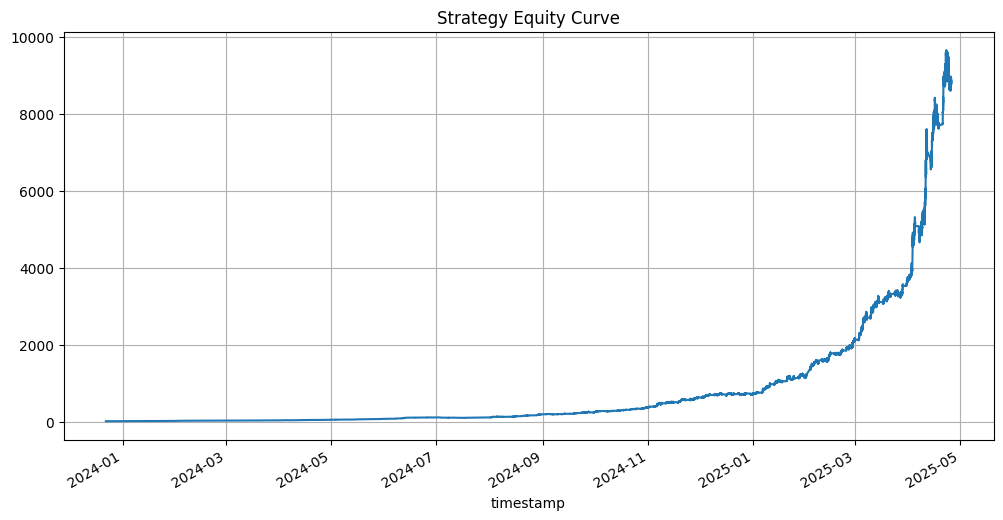

In [28]:
# Calculate and display performance metrics
performance_metrics = calculate_performance_metrics(trades_df, portfolio_df, initial_balance=10)

print("\nPerformance Metrics:")
print(f"Total Trades: {performance_metrics['total_trades']}")
print(f"Win Rate: {performance_metrics['win_rate']:.2f}%")
print(f"Net Profit: ${performance_metrics['net_profit']:.2f}")
print(f"Profit Factor: {performance_metrics['profit_factor']:.2f}")
print(f"Average Trade: ${performance_metrics['avg_trade']:.2f}")
print(f"Max Drawdown: {performance_metrics['max_drawdown_percent']:.2f}%")
print(f"Sharpe Ratio: {performance_metrics['sharpe_ratio']:.2f}")

# Generate and display performance charts
generate_performance_charts(trades_df, portfolio_df, performance_metrics, './strategy_results', 
                          datetime.now().strftime('%Y%m%d_%H%M%S'))

# Display equity curve
plt.figure(figsize=(12, 6))
portfolio_df['equity'].plot(title='Strategy Equity Curve')
plt.grid(True)
plt.show()